#### 10. Comparação de Estratégias de Detecção de Phishing # DESATUALIZADO!

Esta etapa compara duas estratégias do projeto, sem tratá-las como experimentos diretamente equivalentes. O objetivo é apoiar a decisão arquitetural entre um cenário analítico completo e um cenário URL-only voltado para uso em API.

Os resultados devem ser interpretados separadamente, pois os modelos foram treinados e avaliados em bases diferentes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

##### 10.1 Cenários avaliados

A comparação final passa a considerar o contexto de uso de cada abordagem, não apenas as métricas dos modelos.

In [2]:
cenarios = pd.DataFrame({
    "Cenário": [
        "Completo",
        "URL-only"
    ],
    "Notebook de treino": [
        "03_modelagem.ipynb",
        "05_modelagem_url.ipynb"
    ],
    "Dataset": [
        "dataset.csv",
        "urls_dataset.csv"
    ],
    "Entrada do modelo": [
        "Features tabulares já extraídas da URL e da página",
        "URL bruta transformada por feature_extractor.py"
    ],
    "Uso mais adequado": [
        "Análise offline e estudo exploratório",
        "API em tempo real e classificação leve"
    ],
    "Custo operacional": [
        "Maior",
        "Menor"
    ]
})

cenarios

,Cenário,Notebook de treino,Dataset,Entrada do modelo,Uso mais adequado,Custo operacional
0,Completo,03_modelagem.ipynb,dataset.csv,Features tabulares já extraídas da URL e da pá...,Análise offline e estudo exploratório,Maior
1,URL-only,05_modelagem_url.ipynb,urls_dataset.csv,URL bruta transformada por feature_extractor.py,API em tempo real e classificação leve,Menor


##### 10.2 Resultados do cenário completo

O cenário completo utiliza o dataset.csv, composto por atributos já extraídos. Parte desses atributos depende de informações além da URL, como características da página, formulários, hyperlinks e elementos estruturais.

In [3]:
metricas_completo = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.9520,
        0.9650,
        0.9860
    ],
    "Precision": [
        0.9449,
        0.9622,
        0.9880
    ],
    "Recall": [
        0.9600,
        0.9680,
        0.9840
    ],
    "F1-Score": [
        0.9524,
        0.9651,
        0.9860
    ],
    "AUC": [
        0.9869,
        0.9650,
        0.9990
    ]
})

metricas_completo

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regressão Logística,0.952,0.9449,0.960,0.9524,0.9869
1,Decision Tree,0.965,0.9622,0.968,0.9651,0.9650
2,Random Forest,0.986,0.9880,0.984,0.9860,0.9990


##### 10.3 Resultados do cenário URL-only

O cenário URL-only utiliza o urls_dataset.csv, contendo URLs brutas e labels. As features são extraídas pelo mesmo módulo usado na API, garantindo compatibilidade entre treino e inferência.

In [4]:
metricas_url = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.7712,
        0.8525,
        0.8658
    ],
    "Precision": [
        0.4941,
        0.6451,
        0.6804
    ],
    "Recall": [
        0.6271,
        0.7676,
        0.7628
    ],
    "F1-Score": [
        0.5527,
        0.7011,
        0.7192
    ],
    "AUC": [
        0.8187,
        0.8860,
        0.9203
    ]
})

metricas_url

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regressão Logística,0.7712,0.4941,0.6271,0.5527,0.8187
1,Decision Tree,0.8525,0.6451,0.7676,0.7011,0.8860
2,Random Forest,0.8658,0.6804,0.7628,0.7192,0.9203


##### 10.4 Visualização por cenário

Os gráficos abaixo mostram os resultados de cada cenário lado a lado. A leitura correta é comparativa dentro de cada cenário, não como perda causal direta entre bases diferentes.

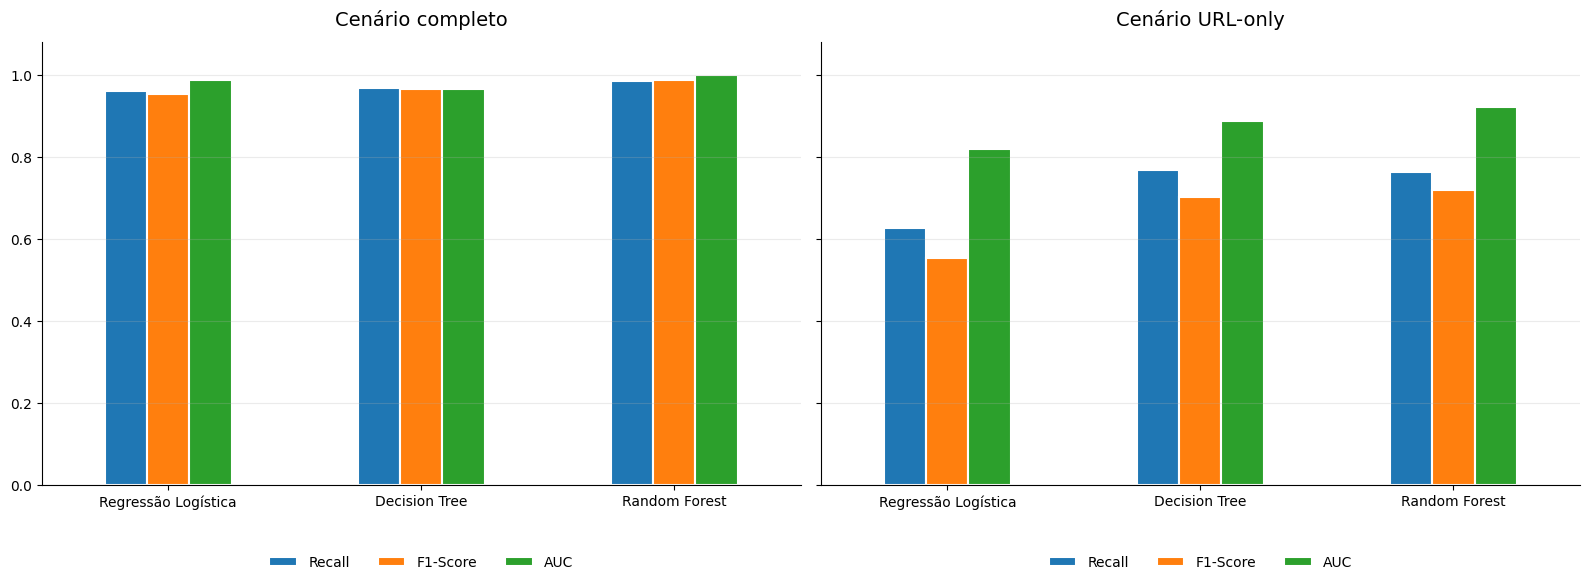

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

metricas_completo.plot(
    x="Modelo",
    y=["Recall", "F1-Score", "AUC"],
    kind="bar",
    ax=axes[0],
    edgecolor="white",
    linewidth=1.5
)

axes[0].set_title("Cenário completo", fontsize=14, pad=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, 1.08)

metricas_url.plot(
    x="Modelo",
    y=["Recall", "F1-Score", "AUC"],
    kind="bar",
    ax=axes[1],
    edgecolor="white",
    linewidth=1.5
)

axes[1].set_title("Cenário URL-only", fontsize=14, pad=12)
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=3)

plt.tight_layout()
plt.show()

##### 10.5 Trade-off arquitetural

A escolha entre os cenários deve considerar desempenho, custo computacional, disponibilidade dos dados e segurança operacional.

In [ ]:
tradeoff = pd.DataFrame({
    "Critério": [
        "Desempenho no experimento",
        "Entrada necessária",
        "Dependência de HTML/página",
        "Latência esperada",
        "Risco ao analisar páginas maliciosas",
        "Adequação para API em tempo real",
        "Interpretabilidade operacional"
    ],
    "Cenário completo": [
        "Maior no dataset original",
        "Features previamente extraídas",
        "Maior",
        "Maior",
        "Maior",
        "Limitada",
        "Boa para análise"
    ],
    "Cenário URL-only": [
        "Menor, porém viável",
        "Apenas a URL bruta",
        "Nenhuma",
        "Menor",
        "Menor",
        "Alta",
        "Boa para regras rápidas"
    ]
})

tradeoff

##### 10.6 Síntese

O cenário completo apresenta desempenho superior no dataset original, mas depende de atributos que não estão necessariamente disponíveis em uma aplicação leve ou em tempo real. Ele é mais adequado para análise offline, estudos exploratórios e comparação de algoritmos em um ambiente com features já consolidadas.

O cenário URL-only apresenta desempenho inferior, mas é mais coerente com a proposta da API do projeto. Ele recebe apenas a URL, extrai atributos localmente com feature_extractor.py e evita carregar páginas potencialmente maliciosas. Essa abordagem reduz latência, custo computacional e risco operacional.

Assim, o Random Forest URL-only é a melhor escolha para o protótipo de produção, enquanto os modelos completos permanecem úteis como referência analítica do potencial máximo de desempenho quando há mais informações disponíveis.

##### 10.7 Limitações

- As métricas dos dois cenários não devem ser interpretadas como comparação causal direta, pois foram obtidas em datasets diferentes.
- O cenário URL-only depende da qualidade e atualidade das URLs do dataset.
- O modelo URL-only pode gerar falsos positivos em URLs legítimas com padrões semelhantes aos de phishing.
- A calibração dos thresholds da API pode ser necessária para equilibrar recall de phishing e falsos positivos.
- Novas estratégias de phishing podem exigir atualização periódica do dataset e retreinamento dos modelos.